<a href="https://colab.research.google.com/github/Kamruzzaman2200/Ai/blob/main/DataMining_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Install dependencies

In [2]:
!pip install ucimlrepo pandas numpy matplotlib seaborn scikit-learn joblib --quiet

#Configuration & imports

In [3]:
RANDOM_STATE = 42
RESULTS_DIR = "/mnt/data/diabetic_analysis_results"
DATA_SAVE_PATH = "/mnt/data/diabetic_data_uci.csv"

import os
os.makedirs(RESULTS_DIR, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# pandas display
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)


#Fetch dataset from UCI repository via ucimlrepo

In [4]:

print("Fetching dataset (id=296)... This may take a few seconds.")
diabetes_uci = fetch_ucirepo(id=296)

# Extract features and targets (as DataFrames)
X = diabetes_uci.data.features
y = diabetes_uci.data.targets

# If targets is a single-column DataFrame/Series, align and combine
if isinstance(y, pd.DataFrame) and y.shape[1]==1:
    y = y.iloc[:,0]
df = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)], axis=1)
print("Fetched dataset shape:", df.shape)
print("Columns:", df.columns.tolist()[:30])


Fetching dataset (id=296)... This may take a few seconds.
Fetched dataset shape: (101766, 48)
Columns: ['race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide']


/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


#Metadata & variable info

In [5]:

print("=== Metadata ===")
print(diabetes_uci.metadata)
print("\n=== First 10 variable rows ===")
try:
    display(diabetes_uci.variables.head(10))
except Exception:
    print("(variable table not available in this object)")


=== Metadata ===
{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failu

,name,role,type,demographic,description,units,missing_values
0,encounter_id,ID,,None,Unique identifier of an encounter,None,no
1,patient_nbr,ID,,None,Unique identifier of a patient,None,no
2,race,Feature,Categorical,Race,"Values: Caucasian, Asian, African American, Hi...",None,yes
3,gender,Feature,Categorical,Gender,"Values: male, female, and unknown/invalid",None,no
4,age,Feature,Categorical,Age,"Grouped in 10-year intervals: [0, 10), [10, 20...",None,no
5,weight,Feature,Categorical,None,Weight in pounds.,None,yes
6,admission_type_id,Feature,Categorical,None,Integer identifier corresponding to 9 distinct...,None,no
7,discharge_disposition_id,Feature,Categorical,None,Integer identifier corresponding to 29 distinc...,None,no
8,admission_source_id,Feature,Categorical,None,Integer identifier corresponding to 21 distinc...,None,no
9,time_in_hospital,Feature,Integer,None,Integer number of days between admission and d...,None,no


#Identify target column and show distribution

In [6]:

if 'readmitted' in df.columns:
    TARGET = 'readmitted'
else:
    # fallback: search for likely candidate
    for cand in ['readmitted','Readmitted','readmit','target']:
        if cand in df.columns:
            TARGET = cand
            break
    else:
        # Heuristic: choose the non-numeric column with <= 10 unique values that looks like a target
        possible = [c for c in df.columns if df[c].dtype == object and df[c].nunique() <= 10]
        TARGET = possible[0] if possible else None

if TARGET is None:
    raise ValueError("Couldn't find a target column automatically. Inspect df.columns and set TARGET manually.")
print("Selected TARGET =", TARGET)
print(df[TARGET].value_counts(dropna=False))


Selected TARGET = readmitted
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


# Basic cleaning (replace '?' with NaN, drop identifiers)

In [7]:

df = df.replace('?', np.nan)

# Drop obvious ID columns if present
drop_cols = [c for c in ['encounter_id', 'patient_nbr'] if c in df.columns]
if drop_cols:
    print("Dropping identifier columns:", drop_cols)
    df = df.drop(columns=drop_cols)

# Quick missing value summary
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing>0].head(40))


,0
weight,98569
max_glu_serum,96420
A1Cresult,84748
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21


#Separate feature lists

In [8]:

# numeric vs categorical detection
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Remove target from categorical list if present
if TARGET in categorical_cols:
    categorical_cols.remove(TARGET)

print("Numeric cols count:", len(numeric_cols))
print("Categorical cols count:", len(categorical_cols))
print("Example numeric cols:", numeric_cols[:10])
print("Example categorical cols:", categorical_cols[:20])


Numeric cols count: 11
Categorical cols count: 36
Example numeric cols: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient']
Example categorical cols: ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide']


#Quick EDA: target vs some key columns

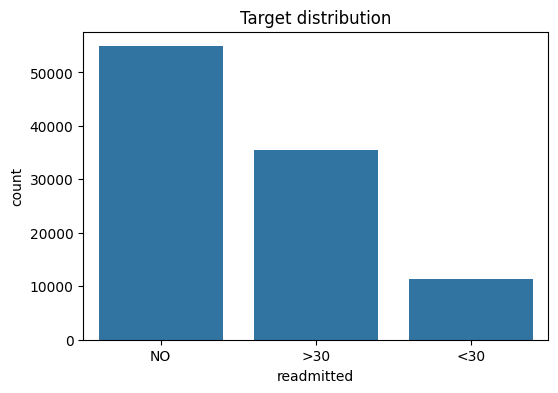

readmitted,<30,>30,NO
age,,,
[0-10),0.018634,0.161491,0.819876
[10-20),0.057887,0.324168,0.617945
[20-30),0.142426,0.307785,0.549789
[30-40),0.112318,0.314437,0.573245
[40-50),0.106040,0.338462,0.555498
[50-60),0.096662,0.342895,0.560443
[60-70),0.111284,0.351243,0.537473
[70-80),0.117731,0.363472,0.518797
[80-90),0.120835,0.361865,0.517300


In [9]:

plt.figure(figsize=(6,4))
sns.countplot(x=TARGET, data=df, order=df[TARGET].value_counts().index)
plt.title("Target distribution")
plt.show()

# Show readmission rate by age bucket if present
if 'age' in df.columns:
    display(pd.crosstab(df['age'], df[TARGET], normalize='index').head(12))


#Prepare preprocessing pipelines (fit on training set only)

In [10]:
num_imputer = SimpleImputer(strategy='median')
num_scaler = StandardScaler()
num_transformer = Pipeline([('imputer', num_imputer), ('scaler', num_scaler)])

# Categorical pipeline
cat_imputer = SimpleImputer(strategy='constant', fill_value='missing')
# OneHotEncoder will create many columns for high-cardinality; this is simple & safe.
cat_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

cat_transformer = Pipeline([('imputer', cat_imputer), ('onehot', cat_encoder)])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numeric_cols),
        ('cat', cat_transformer, categorical_cols)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

#Train/test split (stratify by target)

In [11]:

X = df.drop(columns=[TARGET])
y = df[TARGET].copy()

print("Unique target classes:", y.unique())
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("Train/test shapes:", X_train.shape, X_test.shape)


Unique target classes: ['NO' '>30' '<30']
Train/test shapes: (81412, 47) (20354, 47)


#Baseline pipeline: Logistic Regression

In [12]:
pipe_lr = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=300, random_state=RANDOM_STATE, solver='saga', multi_class='multinomial'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Running cross-validated baseline (Logistic Regression)...")
scores = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
print("LR CV accuracy: mean %.4f ± %.4f" % (scores.mean(), scores.std()))

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
print("Logistic Regression Test accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
joblib.dump(pipe_lr, os.path.join(RESULTS_DIR, "pipeline_logistic.joblib"))


Running cross-validated baseline (Logistic Regression)...
LR CV accuracy: mean 0.5797 ± 0.0026


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression Test accuracy: 0.5793455831777538
              precision    recall  f1-score   support

         <30       0.34      0.02      0.04      2272
         >30       0.50      0.34      0.41      7109
          NO       0.61      0.85      0.71     10973

    accuracy                           0.58     20354
   macro avg       0.48      0.40      0.38     20354
weighted avg       0.54      0.58      0.53     20354



['/mnt/data/diabetic_analysis_results/pipeline_logistic.joblib']

#RandomForest + GridSearch (simple)

In [ ]:
pipe_rf = Pipeline([
    ('preproc', preprocessor),
    ('clf', RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE))
])

param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [10, 20, None],
    'clf__min_samples_split': [2, 5]
}

gs = GridSearchCV(pipe_rf, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
print("Starting GridSearchCV for RandomForest...")
gs.fit(X_train, y_train)
print("Best params:", gs.best_params_)
print("Best CV score:", gs.best_score_)

best_rf = gs.best_estimator_
y_pred_rf = best_rf.predict(X_test)
print("RandomForest Test accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
joblib.dump(best_rf, os.path.join(RESULTS_DIR, "pipeline_randomforest_best.joblib"))


Starting GridSearchCV for RandomForest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


#Feature importances approximation for RandomForest

In [ ]:

def get_feature_names_from_column_transformer(ct: ColumnTransformer):
    feature_names = []
    # For sklearn >=1.0 we can use get_feature_names_out per transformer
    for name, transformer, cols in ct.transformers_:
        if name == 'remainder' and transformer == 'drop':
            continue
        if hasattr(transformer, 'named_steps'):
            last = transformer.named_steps[list(transformer.named_steps.keys())[-1]]
            if hasattr(last, 'get_feature_names_out'):
                names = last.get_feature_names_out(cols)
            else:
                names = cols
        else:
            if hasattr(transformer, 'get_feature_names_out'):
                names = transformer.get_feature_names_out(cols)
            else:
                names = cols
        # prefix to make unique/informative
        prefixed = [f"{name}__{c}" for c in names]
        feature_names.extend(prefixed)
    return feature_names

ct = best_rf.named_steps['preproc']
try:
    feat_names = get_feature_names_from_column_transformer(ct)
except Exception as e:
    print("Warning: could not recover feature names exactly:", e)
    feat_names = None

rf_clf = best_rf.named_steps['clf']
importances = rf_clf.feature_importances_

if feat_names is not None and len(feat_names) == len(importances):
    fi = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(50)
else:
    fi = pd.Series(importances).sort_values(ascending=False).head(50)

print("Top feature importances (approx):")
display(fi)
fi.to_csv(os.path.join(RESULTS_DIR, "feature_importances_top50.csv"))


#Confusion matrix & save reports

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Save classification report for RandomForest
cr = classification_report(y_test, y_pred_rf, output_dict=True)
pd.DataFrame(cr).T.to_csv(os.path.join(RESULTS_DIR, "classification_report_randomforest.csv"))

# Confusion matrix
labels = np.unique(y_test)
cm = confusion_matrix(y_test, y_pred_rf, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, xticks_rotation='vertical')
plt.title("RandomForest Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix_randomforest.png"))
plt.show()

print("Results saved to:", RESULTS_DIR)


# Optional: Binary target conversion (<30 days vs others) and quick re-run

In [ ]:

print("Converting target to binary: '<30' -> 1, else -> 0")
binary_target = (df[TARGET] == "<30").astype(int)
print("Binary distribution:", binary_target.value_counts(normalize=True))

X_b = df.drop(columns=[TARGET])
y_b = binary_target

Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_b, y_b, test_size=0.2, stratify=y_b, random_state=RANDOM_STATE)
pipe_rf_bin = Pipeline([('preproc', preprocessor), ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, n_estimators=200))])
pipe_rf_bin.fit(Xb_train, yb_train)
yb_pred = pipe_rf_bin.predict(Xb_test)
print("Binary RandomForest accuracy:", accuracy_score(yb_test, yb_pred))
print(classification_report(yb_test, yb_pred))
joblib.dump(pipe_rf_bin, os.path.join(RESULTS_DIR, "pipeline_randomforest_binary.joblib"))


#Save dataset locally for reproducibility

In [ ]:
df.to_csv(DATA_SAVE_PATH, index=False)
print("Saved a copy of the dataset to:", DATA_SAVE_PATH)

# List results folder
print("\nFiles in results directory:")
for f in sorted(os.listdir(RESULTS_DIR)):
    print(" -", f)
